In [8]:
# 5_pca_clustering.ipynb

import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

from scipy.sparse import hstack

CSV_PATH = "../outputs/ocr/structured_transactions.csv"
OUT_DIR  = "../outputs/eda/"
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(CSV_PATH, parse_dates=["date"])
print("Rows:", len(df))
df.head(5)


Rows: 191


,date,description,debit,credit,balance,source_image
0,2023-08-08,OO ESSN ot,NaN,350.0,10804.33,2023_August_Statement (6)_page_2_table_1.png
1,2023-08-09,VANTAGE TOYOTA CD 0523,288.0,NaN,10516.33,2023_August_Statement (6)_page_2_table_1.png
2,2023-08-10,HMRC E VAT 0000148023,960.0,NaN,9556.33,2023_August_Statement (6)_page_2_table_1.png
3,2023-08-10,ee NSE,NaN,832.0,10388.33,2023_August_Statement (6)_page_2_table_1.png
4,2023-08-10,$Oo900001179221216 RADIO,500.0,NaN,9888.33,2023_August_Statement (6)_page_2_table_1.png


In [9]:
# numeric coercion
for c in ["debit","credit","balance"]:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

# helper: clean description
def clean_desc(s: str) -> str:
    if not isinstance(s, str): return ""
    s = re.sub(r"\s+", " ", s).strip()
    s = re.sub(r"[^\w\s\-/&.,]", "", s)
    return s.lower()

df["desc_clean"] = df["description"].astype(str).apply(clean_desc)

# features: TF-IDF text + numeric
vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1,2), min_df=2)
X_text = vectorizer.fit_transform(df["desc_clean"])
X_num  = df[["debit","credit","balance"]].values
X = hstack([X_text, X_num])
print("Feature matrix shape:", X.shape)


Feature matrix shape: (191, 141)


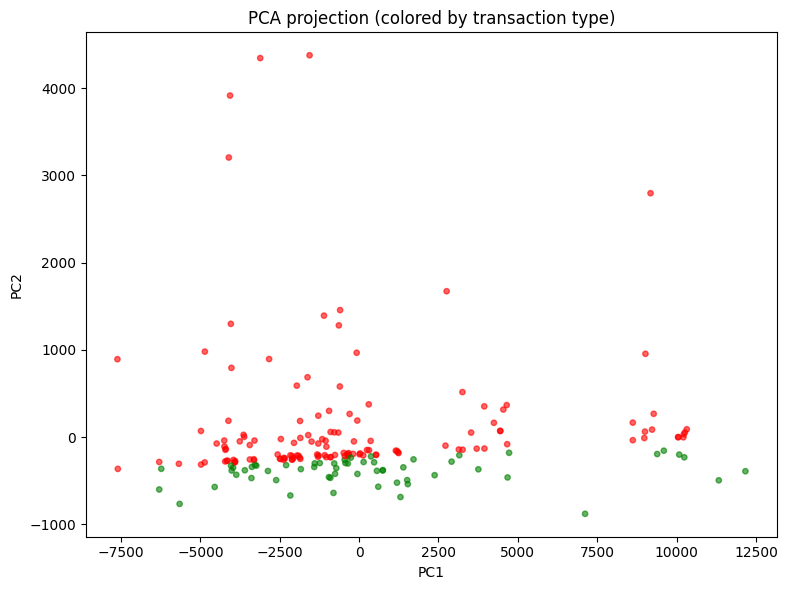

In [10]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X.toarray())   # convert to dense for PCA

df["pca1"], df["pca2"] = X_pca[:,0], X_pca[:,1]

plt.figure(figsize=(8,6))
colors = {"debit":"red","credit":"green","other":"blue"}
df["type"] = np.where(df["debit"]>0,"debit", np.where(df["credit"]>0,"credit","other"))
plt.scatter(df["pca1"], df["pca2"], c=df["type"].map(colors), alpha=0.6, s=15)
plt.title("PCA projection (colored by transaction type)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "pca_type.png"), dpi=160)
plt.show()


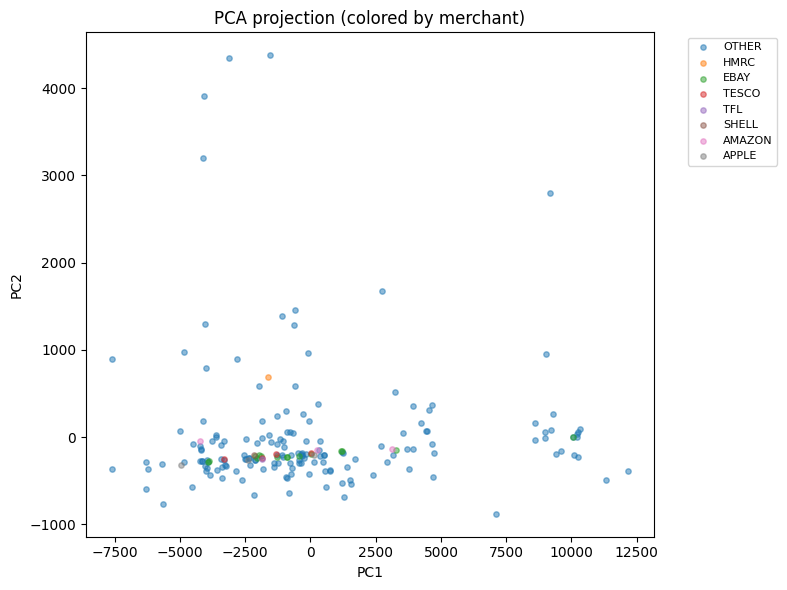

In [11]:
# crude merchant extraction (keywords)
KEYWORDS = ["TESCO","AMAZON","EBAY","PAYPAL","HMRC","SHELL","BP","UBER","TFL","APPLE"]
def extract_merchant(s: str) -> str:
    s = s.upper()
    for k in KEYWORDS:
        if k in s: return k
    return "OTHER"

df["merchant"] = df["desc_clean"].apply(extract_merchant)

plt.figure(figsize=(8,6))
for m in df["merchant"].unique():
    subset = df[df["merchant"]==m]
    plt.scatter(subset["pca1"], subset["pca2"], s=15, alpha=0.5, label=m)
plt.title("PCA projection (colored by merchant)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "pca_merchant.png"), dpi=160)
plt.show()


KMeans clustering

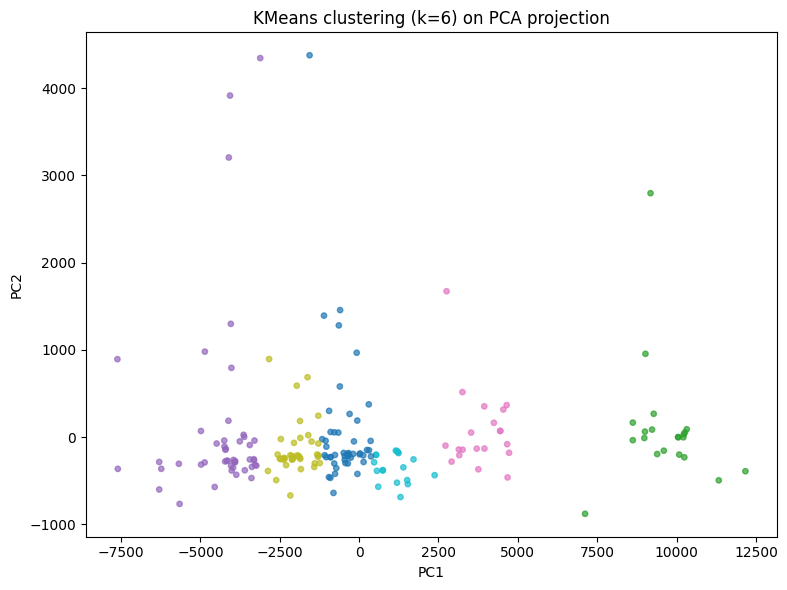

Cluster counts:
 cluster
0    48
2    47
4    37
1    21
3    20
5    18
Name: count, dtype: int64


In [12]:
k = 6  # you can tune this
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X)

df["cluster"] = clusters

plt.figure(figsize=(8,6))
plt.scatter(df["pca1"], df["pca2"], c=df["cluster"], cmap="tab10", s=15, alpha=0.7)
plt.title(f"KMeans clustering (k={k}) on PCA projection")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f"kmeans_pca_k{k}.png"), dpi=160)
plt.show()

print("Cluster counts:\n", df["cluster"].value_counts())


In [13]:
# use Adjusted Rand Index (ARI) to compare clustering vs known merchant labels
ari = adjusted_rand_score(df["merchant"], df["cluster"])
sil = silhouette_score(X, clusters, sample_size=2000)
print(f"Adjusted Rand Index vs merchants: {ari:.3f}")
print(f"Silhouette Score: {sil:.3f}")


Adjusted Rand Index vs merchants: -0.005
Silhouette Score: 0.431


In [14]:
print("Top merchants per cluster:")
print(df.groupby("cluster")["merchant"].value_counts().groupby(level=0).head(5))


Top merchants per cluster:
cluster  merchant
0        OTHER       41
         EBAY         4
         AMAZON       1
         APPLE        1
         TESCO        1
1        OTHER       20
         EBAY         1
2        OTHER       42
         EBAY         2
         AMAZON       1
         APPLE        1
         TESCO        1
3        OTHER       18
         AMAZON       1
         EBAY         1
4        OTHER       26
         EBAY         5
         TESCO        2
         APPLE        1
         HMRC         1
5        OTHER       16
         EBAY         2
Name: count, dtype: int64
